# CIFAR-10 Prediction Notebook (PyTorch Checkpoint)
This notebook uses your trained PyTorch model from `model/cifar10_cnn.pt` for inference only.
`src/` remains from-scratch learning implementation.

In [15]:
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def create_model(num_classes=10, dropout=0.2):
    return nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),

        nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Dropout(dropout),
        nn.Linear(256 * 4 * 4, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(512, num_classes),
    )

Device: cuda


In [16]:
ckpt_path = project_root / 'model' / 'cifar10_cnn.pt'
if not ckpt_path.exists():
    raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')

ckpt = torch.load(ckpt_path, map_location=device)
if not isinstance(ckpt, dict) or 'model_state' not in ckpt:
    raise RuntimeError('Invalid checkpoint format. Expected dict with model_state.')

model = create_model(num_classes=10, dropout=0.2).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()

print('Loaded checkpoint:', ckpt_path)
print('Best accuracy in checkpoint:', float(ckpt.get('best_acc', -1.0)) * 100, '%')

Loaded checkpoint: d:\HUST\GHWorkspace\Convolution-Neutral-Network_from_Scratch\model\cifar10_cnn.pt
Best accuracy in checkpoint: 91.58 %


In [17]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

testset = torchvision.datasets.CIFAR10(
    root=str(project_root / 'data'),
    train=False,
    download=True,
    transform=transform,
)

def predict_batch(x_batch):
    with torch.no_grad():
        logits = model(x_batch.to(device))
        probs = torch.softmax(logits, dim=1)
    return probs.cpu().numpy()

print('Test set size:', len(testset))

Test set size: 10000


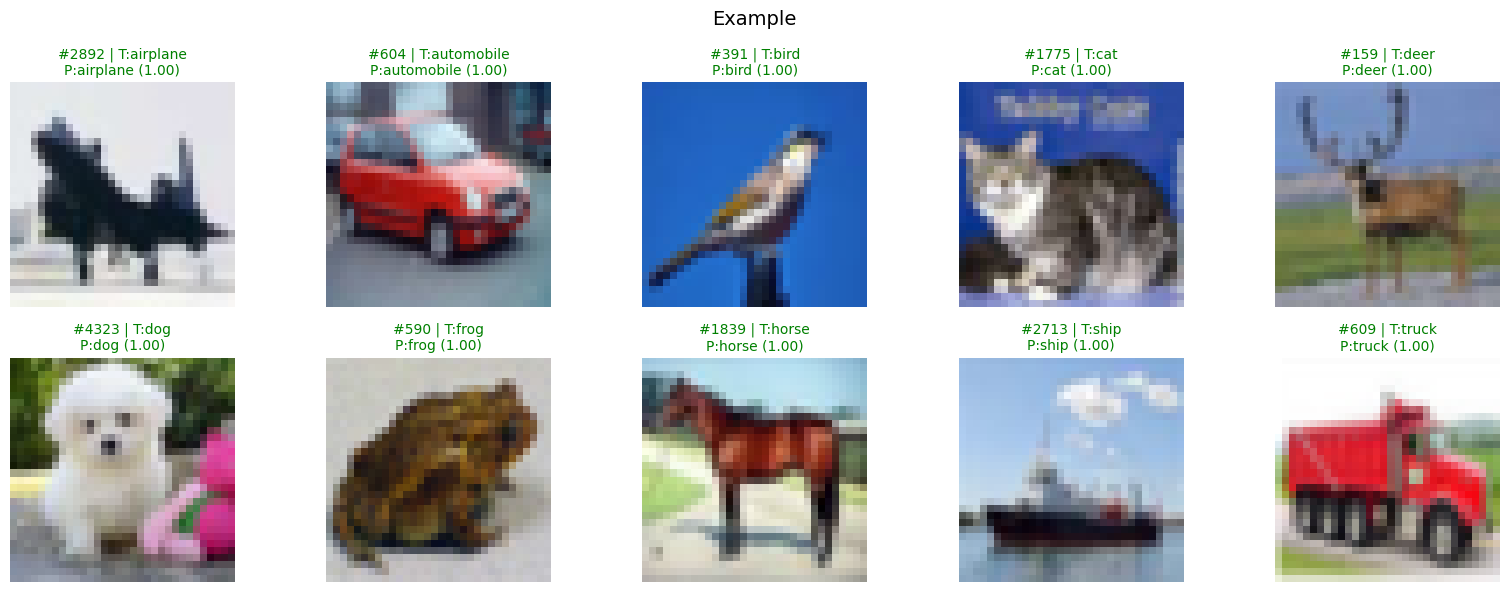

In [23]:
num_show = 10
batch_size = 512

all_probs = []
for start in range(0, len(testset), batch_size):
    end = min(start + batch_size, len(testset))
    x_batch = torch.stack([testset[i][0] for i in range(start, end)])
    probs_batch = predict_batch(x_batch)
    all_probs.append(probs_batch)

all_probs = np.concatenate(all_probs, axis=0)
all_pred = np.argmax(all_probs, axis=1)
all_conf = np.max(all_probs, axis=1)
all_true = np.array(testset.targets)
correct_idx = np.where(all_pred == all_true)[0]

selected = []
for cls in range(10):
    cls_idx = correct_idx[all_true[correct_idx] == cls]
    if len(cls_idx) == 0:
        continue
    best_cls_idx = cls_idx[np.argmax(all_conf[cls_idx])]
    selected.append(int(best_cls_idx))

if len(selected) < num_show:
    ranked_correct = correct_idx[np.argsort(-all_conf[correct_idx])]
    for idx in ranked_correct:
        idx = int(idx)
        if idx not in selected:
            selected.append(idx)
        if len(selected) >= num_show:
            break

selected = selected[:num_show]

cols = 5
rows = 2
plt.figure(figsize=(16, 6))
for i, idx in enumerate(selected):
    img_np = testset.data[idx]
    t = class_names[all_true[idx]]
    p = class_names[all_pred[idx]]
    c = all_conf[idx]

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img_np)
    plt.title(f'#{idx} | T:{t}\nP:{p} ({c:.2f})', color='green', fontsize=10)
    plt.axis('off')

plt.suptitle('Example', fontsize=14)
plt.tight_layout()
plt.show()